In [1]:
# 1. IMPORT LIBRARIES 
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import io
from scipy.fftpack import dct, idct

In [2]:
#  2. LOAD AND DISPLAY IMAGE 
img_url = 'https://upload.wikimedia.org/wikipedia/en/7/7d/Lenna_%28test_image%29.png'
img = io.imread(img_url)

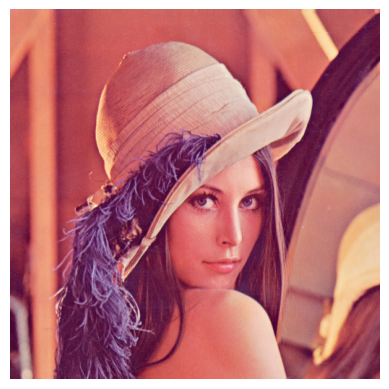

In [44]:
plt.imshow(img)
plt.axis('off')
plt.show()

In [45]:
# 3. CONVERT RGB TO YCbCr 
img_ycbcr = cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb)

In [46]:
# 4. Split the image into Y, Cr, Cb
Y, Cr, Cb = cv2.split(img_ycbcr)

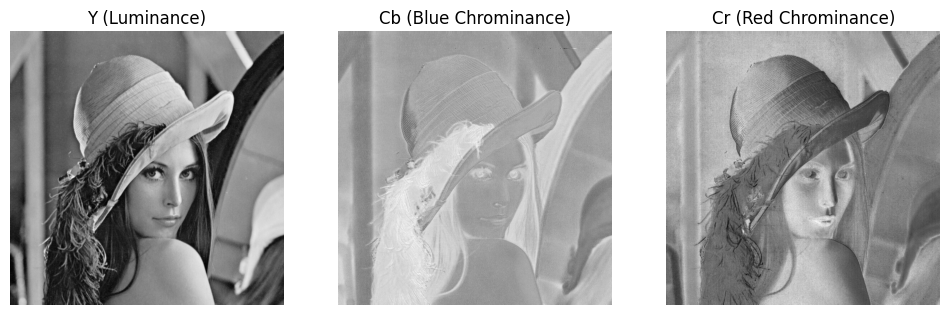

In [6]:
# Visualize channels
plt.figure(figsize=(12, 4))
for i, (channel, title) in enumerate(zip([Y, Cb, Cr], ["Y (Luminance)", "Cb (Blue Chrominance)", "Cr (Red Chrominance)"])):
    plt.subplot(1, 3, i+1)
    plt.imshow(channel, cmap='gray')
    plt.title(title)
    plt.axis('off')
plt.show()

In [7]:
# 5. CHROMA SUBSAMPLING (4:2:0)
def chroma_subsample(channel):
    h, w = channel.shape
    h, w = h - h % 2, w - w % 2

    channel = channel[:h, :w]

    subsampled = np.zeros((h // 2, w // 2), dtype=np.float32)

    for i in range(0, h, 2):
        for j in range(0, w, 2):
            top_left     = channel[i, j]
            top_right    = channel[i, j+1]
            bottom_left  = channel[i+1, j]
            bottom_right = channel[i+1, j+1]

            average = (top_left + top_right + bottom_left + bottom_right) / 4

            subsampled[i//2, j//2] = average

    return subsampled.astype(np.uint8)

In [8]:
Cb_sub = chroma_subsample(Cb)
Cr_sub = chroma_subsample(Cr)

C:\Users\User\AppData\Local\Temp\ipykernel_4628\657463477.py:17: RuntimeWarning: overflow encountered in scalar add
  average = (top_left + top_right + bottom_left + bottom_right) / 4


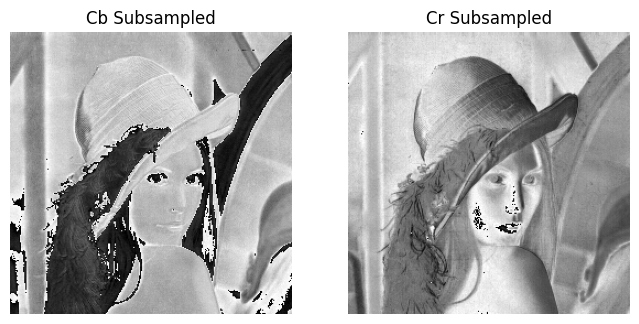

In [9]:
# Visualize subsampled channels
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(Cb_sub, cmap='gray')
plt.title("Cb Subsampled")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(Cr_sub, cmap='gray')
plt.title("Cr Subsampled")
plt.axis('off')
plt.show()

In [10]:
# 6. 8x8 BLOCK DIVISION (ON Y ONLY)
def split_into_blocks(channel, block_size=8):
    h, w = channel.shape
    h_trim = h - (h % block_size)
    w_trim = w - (w % block_size)
    channel = channel[:h_trim, :w_trim]

    blocks = []
    for i in range(0, h_trim, block_size):
        row_blocks = []
        for j in range(0, w_trim, block_size):
            block = channel[i:i+block_size, j:j+block_size]
            row_blocks.append(block)
        blocks.append(row_blocks)

    return np.array(blocks)

In [11]:
blocks = split_into_blocks(Y)

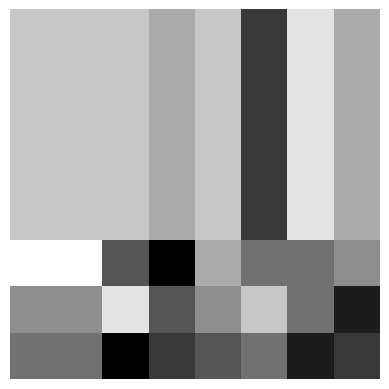

In [47]:
plt.imshow(blocks[0, 0], cmap='gray')
plt.axis('off')
plt.show()

In [13]:
# 7. DCT 
def dct2(block):
    return dct(dct(block.T, norm='ortho').T, norm='ortho')

In [14]:
dct_block = dct2(blocks[0, 0] - 128)

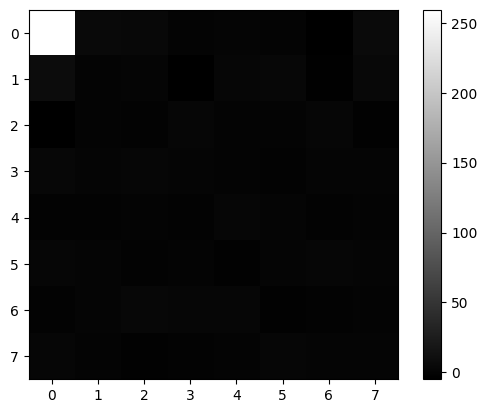

In [48]:
plt.imshow(dct_block, cmap='gray')
plt.colorbar()
plt.show()

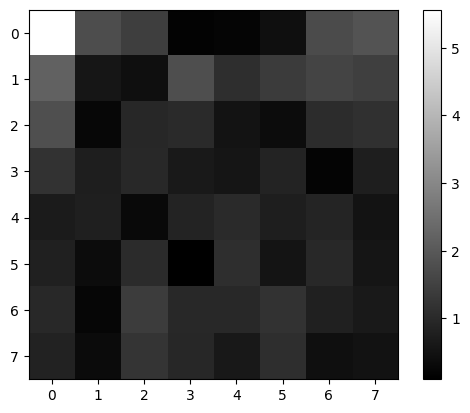

In [49]:
plt.imshow(np.log(np.abs(dct_block) + 1), cmap='gray')
plt.colorbar()
plt.show()

In [17]:
# 8. Quantization
Q = np.array([[16, 11, 10, 16, 24, 40, 51, 61],
            [12, 12, 14, 19, 26, 58, 60, 55],
            [14, 13, 16, 24, 40, 57, 69, 56],
            [14, 17, 22, 29, 51, 87, 80, 62],
            [18, 22, 37, 56, 68, 109, 103, 77],
            [24, 35, 55, 64, 81, 104, 113, 92],
            [49, 64, 78, 87, 103, 121, 120, 101],
            [72, 92, 95, 98, 112, 100, 103, 99]])

quantized_block = dct_block/Q

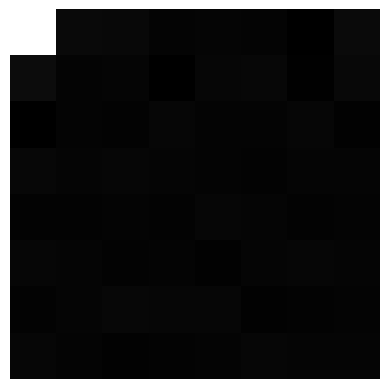

In [50]:
plt.imshow(dct_block, cmap='gray')
plt.axis('off')
plt.show()

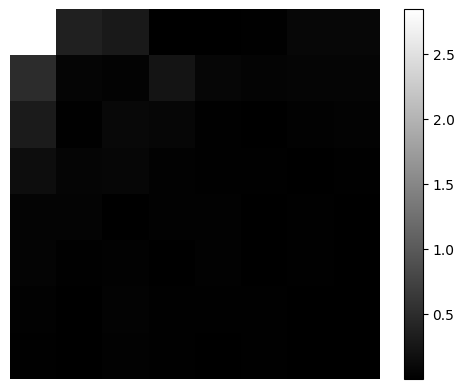

In [54]:
plt.imshow(np.log(np.abs(quantized_block) + 1), cmap='gray')
plt.colorbar()
plt.axis('off')
plt.show()

In [20]:
# 9. Dequantization and IDCT
dequantized_block = quantized_block * Q

In [21]:
def idct2(block):
    return idct(idct(block.T, norm='ortho').T, norm='ortho')

In [22]:
reconstructed_image = idct2(dequantized_block) + 128

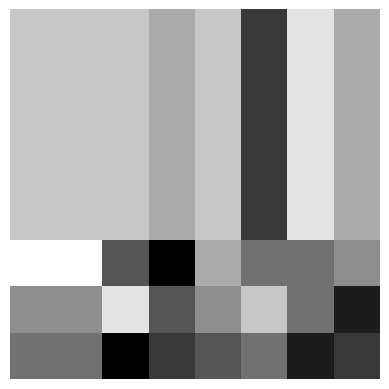

In [53]:
plt.imshow(reconstructed_image, cmap='gray')
plt.axis('off')
plt.show()

In [24]:
import numpy as np
import cv2
from scipy.fftpack import dct, idct

# 8x8 DCT and IDCT
def dct2(block):
    return dct(dct(block.T, norm='ortho').T, norm='ortho')

def idct2(block):
    return idct(idct(block.T, norm='ortho').T, norm='ortho')

# Split into 8x8 blocks
def split_into_blocks(channel):
    h, w = channel.shape
    assert h % 8 == 0 and w % 8 == 0, "Image must be divisible by 8"
    blocks = []
    for i in range(0, h, 8):
        for j in range(0, w, 8):
            blocks.append(channel[i:i+8, j:j+8])
    return blocks

# JPEG-like compression
def jpeg_compress(img, Q, subsample=True):
    # Convert RGB to YCrCb
    img_ycbcr = cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb)
    Y, Cr, Cb = cv2.split(img_ycbcr)

    # Ensure image is divisible by 8
    def pad_image(channel):
        h, w = channel.shape
        pad_h = (8 - h % 8) % 8
        pad_w = (8 - w % 8) % 8
        return np.pad(channel, ((0, pad_h), (0, pad_w)), mode='constant')

    Y = pad_image(Y)
    Cr = pad_image(Cr)
    Cb = pad_image(Cb)

    if subsample:
        Cr = cv2.resize(Cr, (Cr.shape[1] // 2, Cr.shape[0] // 2), interpolation=cv2.INTER_LINEAR)
        Cb = cv2.resize(Cb, (Cb.shape[1] // 2, Cb.shape[0] // 2), interpolation=cv2.INTER_LINEAR)

    def compress_channel(channel, Q):
        h, w = channel.shape
        blocks = split_into_blocks(channel)
        dct_blocks = [dct2(block) for block in blocks]
        quant_blocks = [(dct_block / Q) for dct_block in dct_blocks]
        dequant_blocks = [quant * Q for quant in quant_blocks]
        idct_blocks = [idct2(block) for block in dequant_blocks]

        # Reconstruct the image
        out = np.zeros((h, w))
        idx = 0
        for i in range(0, h, 8):
            for j in range(0, w, 8):
                out[i:i+8, j:j+8] = idct_blocks[idx]
                idx += 1
        return np.clip(out, 0, 255).astype(np.uint8)

    Y_comp = compress_channel(Y, Q)

    # Upsample if chroma was subsampled
    if subsample:
        Cr = cv2.resize(Cr, (Y.shape[1], Y.shape[0]), interpolation=cv2.INTER_LINEAR)
        Cb = cv2.resize(Cb, (Y.shape[1], Y.shape[0]), interpolation=cv2.INTER_LINEAR)

    # Merge and convert back to RGB
    ycbcr_merged = cv2.merge([Y_comp, Cr, Cb])
    rgb_reconstructed = cv2.cvtColor(ycbcr_merged, cv2.COLOR_YCrCb2RGB)

    return rgb_reconstructed


In [39]:
# COMPRESS THE FULL IMAGE using the jpeg_compress function
compressed_img = jpeg_compress(img, Q, subsample=True)

In [40]:
# 11. PSNR CALCULATION
def psnr(original, compressed):
    mse = np.mean((original - compressed) ** 2)
    if mse == 0:
        return float('inf')
    PIXEL_MAX = 255.0
    return 20 * np.log10(PIXEL_MAX / np.sqrt(mse))

In [41]:
psnr_1 = psnr(blocks[0,0], reconstructed_image)
psnr_1

inf

In [42]:
psnr_val = psnr(img.astype(np.float32), compressed_img.astype(np.float32))

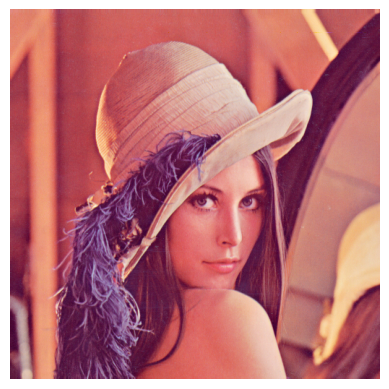

In [37]:
plt.imshow(compressed_img)
plt.axis('off')
plt.show()

In [43]:
print(f"The psnr value is: {psnr_val} dB")

The psnr value is: 37.532379150390625 dB


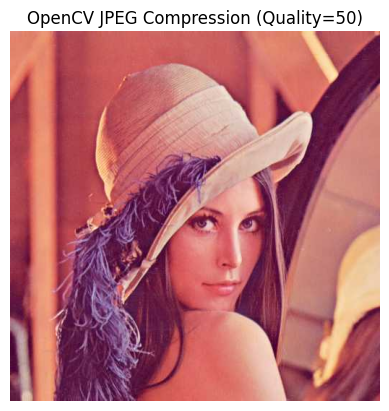

PSNR with OpenCV JPEG:  32.017063


In [31]:
# 12. BONUS TASKS 
# a. Try different Q matrices
# b. Set subsample=False in jpeg_compress() to disable chroma subsampling
# c. Compare OpenCV JPEG
_, encoded = cv2.imencode('.jpg', cv2.cvtColor(img, cv2.COLOR_RGB2BGR), [int(cv2.IMWRITE_JPEG_QUALITY), 50])
decoded = cv2.imdecode(encoded, 1)
decoded_rgb = cv2.cvtColor(decoded, cv2.COLOR_BGR2RGB)

plt.imshow(decoded_rgb)
plt.title("OpenCV JPEG Compression (Quality=50)")
plt.axis('off')
plt.show()

print("PSNR with OpenCV JPEG: ", psnr(img.astype(np.float32), decoded_rgb.astype(np.float32)))